In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 924.3 kB/s  0:00:014.9 kB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 1.2 MB/s  0:00:41 eta 0:00:010:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 1.7 MB/s  0:00:001.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 1.8 MB/s  0:00:22a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 1.4 MB/s  0:00:48 eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 1.4 MB/s  0:00:011.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [ultralytics] 6/7 [ultralytics]vision]n]


In [16]:
%matplotlib inline

In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/senanayaka/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import matplotlib.pyplot as plt
import cv2
import os

In [7]:
model = YOLO("/Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/best.pt")

In [9]:
data_yaml = """
train: /Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/image1/train/images
val: /Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/image1/valid/images
test: /Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/image1/test/images

nc: 8

names:
  - Chicken Bun
  - Chicken Cutlet
  - Chicken Pastry
  - Chicken Rolls
  - Chicken Rotti
  - Iced Coffee
  - Milk Rice
  - Pizza - Cheese Lovers
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created!")

data.yaml created!


In [10]:
metrics = model.val(data="data.yaml", split="test", save=True)
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.13.9 torch-2.11.0 CPU (Apple M5)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 188.5±52.4 MB/s, size: 29.4 KB)
val: Scanning /Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/image1/test/labels... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 350.9it/s 0.0s
val: New cache created: /Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/image1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.0it/s 0.3s
                   all          8          8      0.935          1      0.995      0.983
           Chicken Bun          1          1      0.944          1      0.995      0.995
        Chicken Cutlet          1          1      0.924          1      0.995      0.995
        Chicken Pastry          1          1      0.971          1      0.995      0.995
         Chicken Rolls          1          1      0.909          1      0.995      0.995
         Chicken Ro

In [11]:
import os
print(os.path.exists("data.yaml"))

True


In [12]:
metrics = model.val(data="data.yaml", split="test", save=True)
print(metrics)

Ultralytics 8.4.37 🚀 Python-3.13.9 torch-2.11.0 CPU (Apple M5)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 133.3±31.0 MB/s, size: 29.4 KB)
val: Scanning /Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/image1/test/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 3.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.9it/s 0.3s
                   all          8          8      0.935          1      0.995      0.983
           Chicken Bun          1          1      0.944          1      0.995      0.995
        Chicken Cutlet          1          1      0.924          1      0.995      0.995
        Chicken Pastry          1          1      0.971          1      0.995      0.995
         Chicken Rolls          1          1      0.909          1      0.995      0.995
         Chicken Rotti          1          1      0.933          1      0.995      0.995
           Iced Coffee      

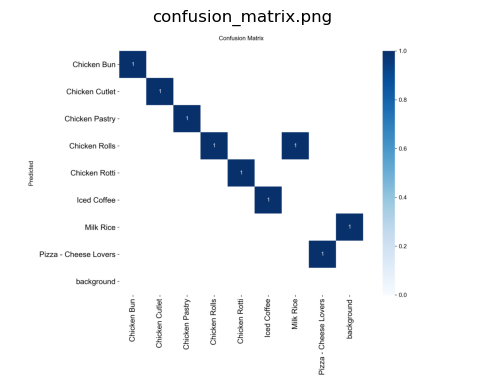

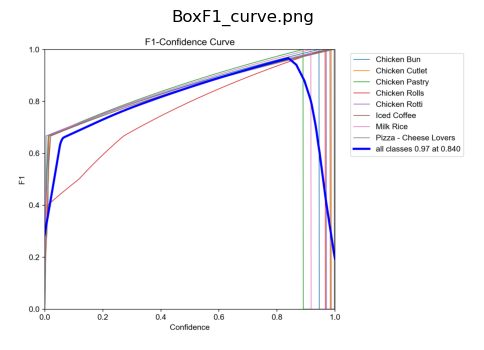

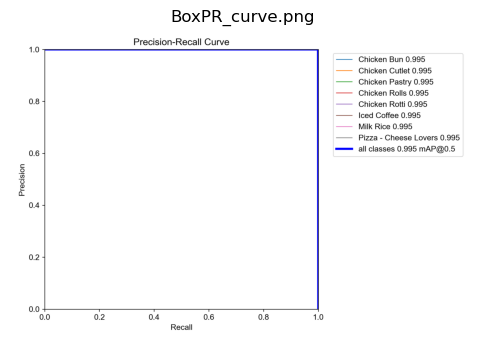

In [17]:
import cv2
import matplotlib.pyplot as plt
import os

results_path = "/Users/senanayaka/SLIIT/Y2S2/AI Project 2021/AI PARTS/runs/detect/val3"

images = [
    "confusion_matrix.png",
    "BoxF1_curve.png",
    "BoxPR_curve.png"
]

for img in images:
    path = os.path.join(results_path, img)
    
    if os.path.exists(path):
        image = cv2.imread(path)
        
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(6,6))
            plt.imshow(image)
            plt.title(img)
            plt.axis("off")
            plt.show()

In [15]:
print("mAP@0.5:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP@0.5: 0.995
Precision: 0.9353280522945271
Recall: 1.0
